Leah's Cleaning section


In [ ]:
import numpy as np
import pandas as pd
import time
import os

In [ ]:
#connect to my drive
from google.colab import drive
drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

SHARED_DRIVE_PATH = '/content/drive/MyDrive/Energy Data Analysis Group 3 Coursework/data/Merged/'

# Ensure the directory exists (optional, but good practice)
os.makedirs(SHARED_DRIVE_PATH, exist_ok=True)

In [ ]:
merged = pd.read_csv(SHARED_DRIVE_PATH + 'Merged File (Removed Columns).csv')

In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71925 entries, 0 to 71924
Data columns (total 37 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   date_sp                                          71925 non-null  object 
 1   demand-forecast                                  71871 non-null  float64
 2   demand-outturn                                   71871 non-null  float64
 3   absolute-error                                   71871 non-null  float64
 4   nd                                               71925 non-null  int64  
 5   tsd                                              71925 non-null  int64  
 6   england_wales_demand                             71925 non-null  int64  
 7   embedded_wind_generation                         71925 non-null  int64  
 8   embedded_wind_capacity                           71925 non-null  int64  
 9   embedded_solar_generation   

In [ ]:
merged.shape

(71925, 37)

In [ ]:
merged.head()

,date_sp,demand-forecast,demand-outturn,absolute-error,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
0,2021-04-01-01,21570.0,19970.0,1600.0,19994,21312,18253,2046,6527,0,...,0.0,0.0,723.0,4898.0,153.0,0.0,2264.986,4179.700,54.31,NaN
1,2021-04-01-02,21130.0,20030.0,1100.0,19999,21438,18244,2095,6527,0,...,0.0,0.0,723.0,4884.0,150.0,0.0,2490.455,3707.783,46.73,NaN
2,2021-04-01-03,21272.0,20499.0,773.0,20482,21701,18745,2082,6527,0,...,0.0,0.0,721.0,4895.0,162.0,0.0,3707.667,3562.915,43.00,NaN
3,2021-04-01-04,21600.0,20940.0,660.0,20926,21723,19183,2091,6527,0,...,0.0,0.0,720.0,4894.0,148.0,0.0,3930.858,3677.153,46.65,NaN
4,2021-04-01-05,21478.0,20682.0,796.0,20685,21728,18945,2178,6527,0,...,0.0,0.0,704.0,4894.0,149.0,0.0,3854.118,3673.495,51.15,NaN


In [ ]:
#check for dupliates
duplicate_dates = merged[merged.duplicated(subset=['date_sp'], keep=False)]
display(duplicate_dates)
print(f"duplicate date_sp count: {len(duplicate_dates)}")

,date_sp,demand-forecast,demand-outturn,absolute-error,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
4377,2021-07-01-10,20080.0,19711.0,369.0,19710,21408,17943,537,6527,0,...,0.0,0.0,55.0,4679.0,139.0,1.0,2214.158,405.494,93.20,16.1
4378,2021-07-01-10,20080.0,19711.0,369.0,19710,21408,17943,537,6527,0,...,0.0,0.0,55.0,4679.0,139.0,1.0,2214.158,405.494,93.20,16.1
4379,2021-07-01-11,20612.0,20120.0,492.0,20103,21385,18303,499,6527,57,...,0.0,0.0,53.0,4675.0,139.0,34.0,2229.429,403.213,98.12,16.1
4380,2021-07-01-11,20612.0,20120.0,492.0,20103,21385,18303,499,6527,57,...,0.0,0.0,53.0,4675.0,139.0,34.0,2229.429,403.213,98.12,16.1
4381,2021-07-01-12,21580.0,20939.0,641.0,20896,21872,19026,478,6527,273,...,0.0,0.0,53.0,4679.0,159.0,199.0,2126.391,405.668,92.69,16.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70434,2025-03-01-46,28570.0,28150.0,420.0,28288,30252,25824,762,6606,0,...,0.0,0.0,546.0,4202.0,319.0,0.0,2386.018,2308.548,99.72,5.7
70435,2025-03-01-47,27113.0,26855.0,258.0,26998,28968,24647,797,6606,0,...,0.0,0.0,527.0,4205.0,280.0,0.0,2613.762,2377.181,96.17,5.7
70436,2025-03-01-47,27113.0,26855.0,258.0,26998,28968,24647,797,6606,0,...,0.0,0.0,527.0,4205.0,280.0,0.0,2613.762,2377.181,96.17,5.7
70437,2025-03-01-48,26450.0,25719.0,731.0,25846,27946,23556,832,6606,0,...,0.0,0.0,523.0,4209.0,285.0,0.0,2644.029,2232.582,103.20,5.7


duplicate date_sp count: 3518


In [ ]:
# I want to make sure there aren't any more than 2 duplicates
sp_dup_count = merged['date_sp'].value_counts()

multiple_SP_dates = date_counts[date_counts > 2].index

rows_with_more_than_one_duplicate = merged[merged['date_sp'].isin(multiple_SP_dates)]

display(rows_with_more_than_one_duplicate)
print(f"'date_sp' appearing more than twice: {len(rows_with_more_than_one_duplicate)}")

,date_sp,demand-forecast,demand-outturn,absolute-error,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature


'date_sp' appearing more than twice: 0


In [ ]:
print(f"DataFrame shape before removing duplicates: {merged.shape}")

# removed duplicated date_sp, just keep first
merged_cleaned = merged.drop_duplicates(subset=['date_sp'], keep='first')

print(f"DataFrame shape after removing duplicates: {merged_cleaned.shape}")

# You might want to update your original 'merged' DataFrame with the cleaned version
merged = merged_cleaned.copy()


DataFrame shape before removing duplicates: (71925, 37)
DataFrame shape after removing duplicates: (70166, 37)


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70166 entries, 0 to 71924
Data columns (total 37 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   date_sp                                          70166 non-null  object 
 1   demand-forecast                                  70112 non-null  float64
 2   demand-outturn                                   70112 non-null  float64
 3   absolute-error                                   70112 non-null  float64
 4   nd                                               70166 non-null  int64  
 5   tsd                                              70166 non-null  int64  
 6   england_wales_demand                             70166 non-null  int64  
 7   embedded_wind_generation                         70166 non-null  int64  
 8   embedded_wind_capacity                           70166 non-null  int64  
 9   embedded_solar_generation        

In [ ]:
merged.drop(columns=['absolute-error', 'non_bm_stor'], inplace=True)

merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70166 entries, 0 to 71924
Data columns (total 35 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   date_sp                                          70166 non-null  object 
 1   demand-forecast                                  70112 non-null  float64
 2   demand-outturn                                   70112 non-null  float64
 3   nd                                               70166 non-null  int64  
 4   tsd                                              70166 non-null  int64  
 5   england_wales_demand                             70166 non-null  int64  
 6   embedded_wind_generation                         70166 non-null  int64  
 7   embedded_wind_capacity                           70166 non-null  int64  
 8   embedded_solar_generation                        70166 non-null  int64  
 9   embedded_solar_capacity          

In [ ]:
print(f"DataFrame shape before dropping rows with nulls in specified columns: {merged.shape}")

columns_for_dropping_null = [
    'demand-forecast',
    'demand-outturn',
    'deratedmargin',
    'lossofloadprobability',
    'interconnector_net_generation(mw)',
    'sumpn',
    'noav_total_accepted_volume_per_period',
    'noav_proportion_of_short_period_volumes_to_long',
    'nbav_total_accepted_volume_per_period',
    'nbav_proportion_of_short_period_volumes_to_long',
    'biomass',
    'fossil gas',
    'fossil hard coal',
    'fossil oil',
    'hydro pumped storage',
    'hydro run-of-river and poundage',
    'nuclear',
    'other',
    'solar',
    'wind offshore',
    'wind onshore',
    'market_index_price']

merged.dropna(subset=columns_for_dropping_null, inplace=True)

print(f"DataFrame shape after dropping rows with nulls in specified columns: {merged.shape}")

# Display null counts for verification after cleaning
print("\nNull counts after cleaning:")
display(merged.isnull().sum())

DataFrame shape before dropping rows with nulls in specified columns: (70166, 35)
DataFrame shape after dropping rows with nulls in specified columns: (67262, 35)

Null counts after cleaning:


,0
date_sp,0
demand-forecast,0
demand-outturn,0
nd,0
tsd,0
england_wales_demand,0
embedded_wind_generation,0
embedded_wind_capacity,0
embedded_solar_generation,0
embedded_solar_capacity,0


In [ ]:
print(f"Null count for 'Temperature' before backfilling: {merged['Temperature'].isnull().sum()}")

# Backfill null values in the 'Temperature' column
merged['Temperature'].bfill(inplace=True)

print(f"Null count for 'Temperature' after backfilling: {merged['Temperature'].isnull().sum()}")

# Display overall null counts to see if any other columns were affected (they shouldn't be)
print("\nOverall null counts after backfilling 'Temperature':")
display(merged.isnull().sum())

Null count for 'Temperature' before backfilling: 4610
Null count for 'Temperature' after backfilling: 0

Overall null counts after backfilling 'Temperature':


/tmp/ipython-input-368632342.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged['Temperature'].bfill(inplace=True)


,0
date_sp,0
demand-forecast,0
demand-outturn,0
nd,0
tsd,0
england_wales_demand,0
embedded_wind_generation,0
embedded_wind_capacity,0
embedded_solar_generation,0
embedded_solar_capacity,0


In [ ]:
# Define the full path for the new CSV file
output_file_path = os.path.join(SHARED_DRIVE_PATH, 'merged_cleaned_data_for_EDA.csv')

# Save the cleaned DataFrame to CSV
merged.to_csv(output_file_path, index=False)


**Ahana's EDA part:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Make plots look nicer
sns.set(style="whitegrid", font_scale=1.1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Copy of merged_cleaned_data_for_EDA.csv"
df = pd.read_csv(file_path)

df.head()


,date_sp,demand-forecast,demand-outturn,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
0,2021-04-01-01,21570.0,19970.0,19994,21312,18253,2046,6527,0,13637,...,0.0,0.0,723.0,4898.0,153.0,0.0,2264.986,4179.700,54.31,16.0
1,2021-04-01-02,21130.0,20030.0,19999,21438,18244,2095,6527,0,13642,...,0.0,0.0,723.0,4884.0,150.0,0.0,2490.455,3707.783,46.73,16.0
2,2021-04-01-03,21272.0,20499.0,20482,21701,18745,2082,6527,0,13642,...,0.0,0.0,721.0,4895.0,162.0,0.0,3707.667,3562.915,43.00,16.0
3,2021-04-01-04,21600.0,20940.0,20926,21723,19183,2091,6527,0,13642,...,0.0,0.0,720.0,4894.0,148.0,0.0,3930.858,3677.153,46.65,16.0
4,2021-04-01-05,21478.0,20682.0,20685,21728,18945,2178,6527,0,13642,...,0.0,0.0,704.0,4894.0,149.0,0.0,3854.118,3673.495,51.15,16.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67262 entries, 0 to 67261
Data columns (total 35 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   date_sp                                          67262 non-null  object 
 1   demand-forecast                                  67262 non-null  float64
 2   demand-outturn                                   67262 non-null  float64
 3   nd                                               67262 non-null  int64  
 4   tsd                                              67262 non-null  int64  
 5   england_wales_demand                             67262 non-null  int64  
 6   embedded_wind_generation                         67262 non-null  int64  
 7   embedded_wind_capacity                           67262 non-null  int64  
 8   embedded_solar_generation                        67262 non-null  int64  
 9   embedded_solar_capacity     

In [ ]:
df.isna().sum()


,0
date_sp,0
demand-forecast,0
demand-outturn,0
nd,0
tsd,0
england_wales_demand,0
embedded_wind_generation,0
embedded_wind_capacity,0
embedded_solar_generation,0
embedded_solar_capacity,0


In [ ]:
df.describe()


,demand-forecast,demand-outturn,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,pump_storage_pumping,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
count,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,...,67262.0,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000
mean,26768.787309,26742.706461,26779.134876,28859.959695,24541.134132,1817.518108,6549.572240,1513.513366,15910.894948,200.367280,...,0.0,207.533050,357.208022,4325.278567,292.786209,1331.286462,3127.948609,3148.012821,119.413743,12.076205
std,6048.100897,6035.096742,6059.254417,5754.745650,5539.194235,1166.094071,34.170001,2347.339063,1821.666068,372.086545,...,0.0,376.787894,254.175471,1345.743418,256.071126,2064.463937,2901.433470,2274.769556,86.351079,5.028230
min,13800.000000,13598.000000,13601.000000,16513.000000,12850.000000,125.000000,6488.000000,0.000000,13637.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-38.506000,0.000000,-77.290000,-1.900000
25%,22087.000000,22005.250000,22033.250000,24516.000000,20203.000000,886.000000,6527.000000,0.000000,14141.000000,7.000000,...,0.0,0.000000,139.000000,4099.000000,145.000000,0.000000,680.169500,1270.787000,72.560000,8.300000
50%,26040.000000,26029.500000,26055.000000,28068.500000,23835.000000,1515.000000,6545.000000,4.000000,15593.000000,11.000000,...,0.0,0.000000,324.000000,4632.000000,210.000000,10.000000,2163.338000,2513.723500,95.840000,12.100000
75%,30609.000000,30587.000000,30636.750000,32398.750000,28085.000000,2508.000000,6562.000000,2466.000000,17236.000000,148.000000,...,0.0,257.000000,531.000000,5091.000000,356.000000,2150.000000,5144.618500,4604.592500,142.720000,16.000000
max,46760.000000,46042.000000,46147.000000,47517.000000,42458.000000,5962.000000,6622.000000,13045.000000,20155.000000,1854.000000,...,0.0,2473.000000,1181.000000,6830.000000,2970.000000,11594.000000,12207.978000,11207.950000,1893.020000,27.600000


In [ ]:
cols = [
    'date_sp',
    'demand-forecast', 'demand-outturn', 'nd', 'tsd', 'england_wales_demand',
    'embedded_wind_generation', 'embedded_wind_capacity',
    'embedded_solar_generation', 'embedded_solar_capacity',
    'pump_storage_pumping', 'deratedmargin', 'lossofloadprobability',
    'interconnector_net_generation(mw)', 'systemprice', 'netimbalancevolume',
    'gas price (£/mwh)', 'sumpn',
    'noav_total_accepted_volume_per_period',
    'noav_proportion_of_short_period_volumes_to_long',
    'nbav_total_accepted_volume_per_period',
    'nbav_proportion_of_short_period_volumes_to_long',
    'biomass', 'fossil gas', 'fossil hard coal',
    'hydro pumped storage', 'hydro run-of-river and poundage',
    'nuclear', 'other', 'solar', 'wind offshore', 'wind onshore',
    'market_index_price', 'Temperature'
]



In [ ]:
# Check missing values
df[cols].isna().sum()

# Summary stats
df[cols].describe()


,demand-forecast,demand-outturn,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,pump_storage_pumping,...,fossil hard coal,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
count,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,...,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000,67262.000000
mean,26768.787309,26742.706461,26779.134876,28859.959695,24541.134132,1817.518108,6549.572240,1513.513366,15910.894948,200.367280,...,296.143142,207.533050,357.208022,4325.278567,292.786209,1331.286462,3127.948609,3148.012821,119.413743,12.076205
std,6048.100897,6035.096742,6059.254417,5754.745650,5539.194235,1166.094071,34.170001,2347.339063,1821.666068,372.086545,...,452.335425,376.787894,254.175471,1345.743418,256.071126,2064.463937,2901.433470,2274.769556,86.351079,5.028230
min,13800.000000,13598.000000,13601.000000,16513.000000,12850.000000,125.000000,6488.000000,0.000000,13637.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-38.506000,0.000000,-77.290000,-1.900000
25%,22087.000000,22005.250000,22033.250000,24516.000000,20203.000000,886.000000,6527.000000,0.000000,14141.000000,7.000000,...,0.000000,0.000000,139.000000,4099.000000,145.000000,0.000000,680.169500,1270.787000,72.560000,8.300000
50%,26040.000000,26029.500000,26055.000000,28068.500000,23835.000000,1515.000000,6545.000000,4.000000,15593.000000,11.000000,...,0.000000,0.000000,324.000000,4632.000000,210.000000,10.000000,2163.338000,2513.723500,95.840000,12.100000
75%,30609.000000,30587.000000,30636.750000,32398.750000,28085.000000,2508.000000,6562.000000,2466.000000,17236.000000,148.000000,...,474.000000,257.000000,531.000000,5091.000000,356.000000,2150.000000,5144.618500,4604.592500,142.720000,16.000000
max,46760.000000,46042.000000,46147.000000,47517.000000,42458.000000,5962.000000,6622.000000,13045.000000,20155.000000,1854.000000,...,3035.000000,2473.000000,1181.000000,6830.000000,2970.000000,11594.000000,12207.978000,11207.950000,1893.020000,27.600000


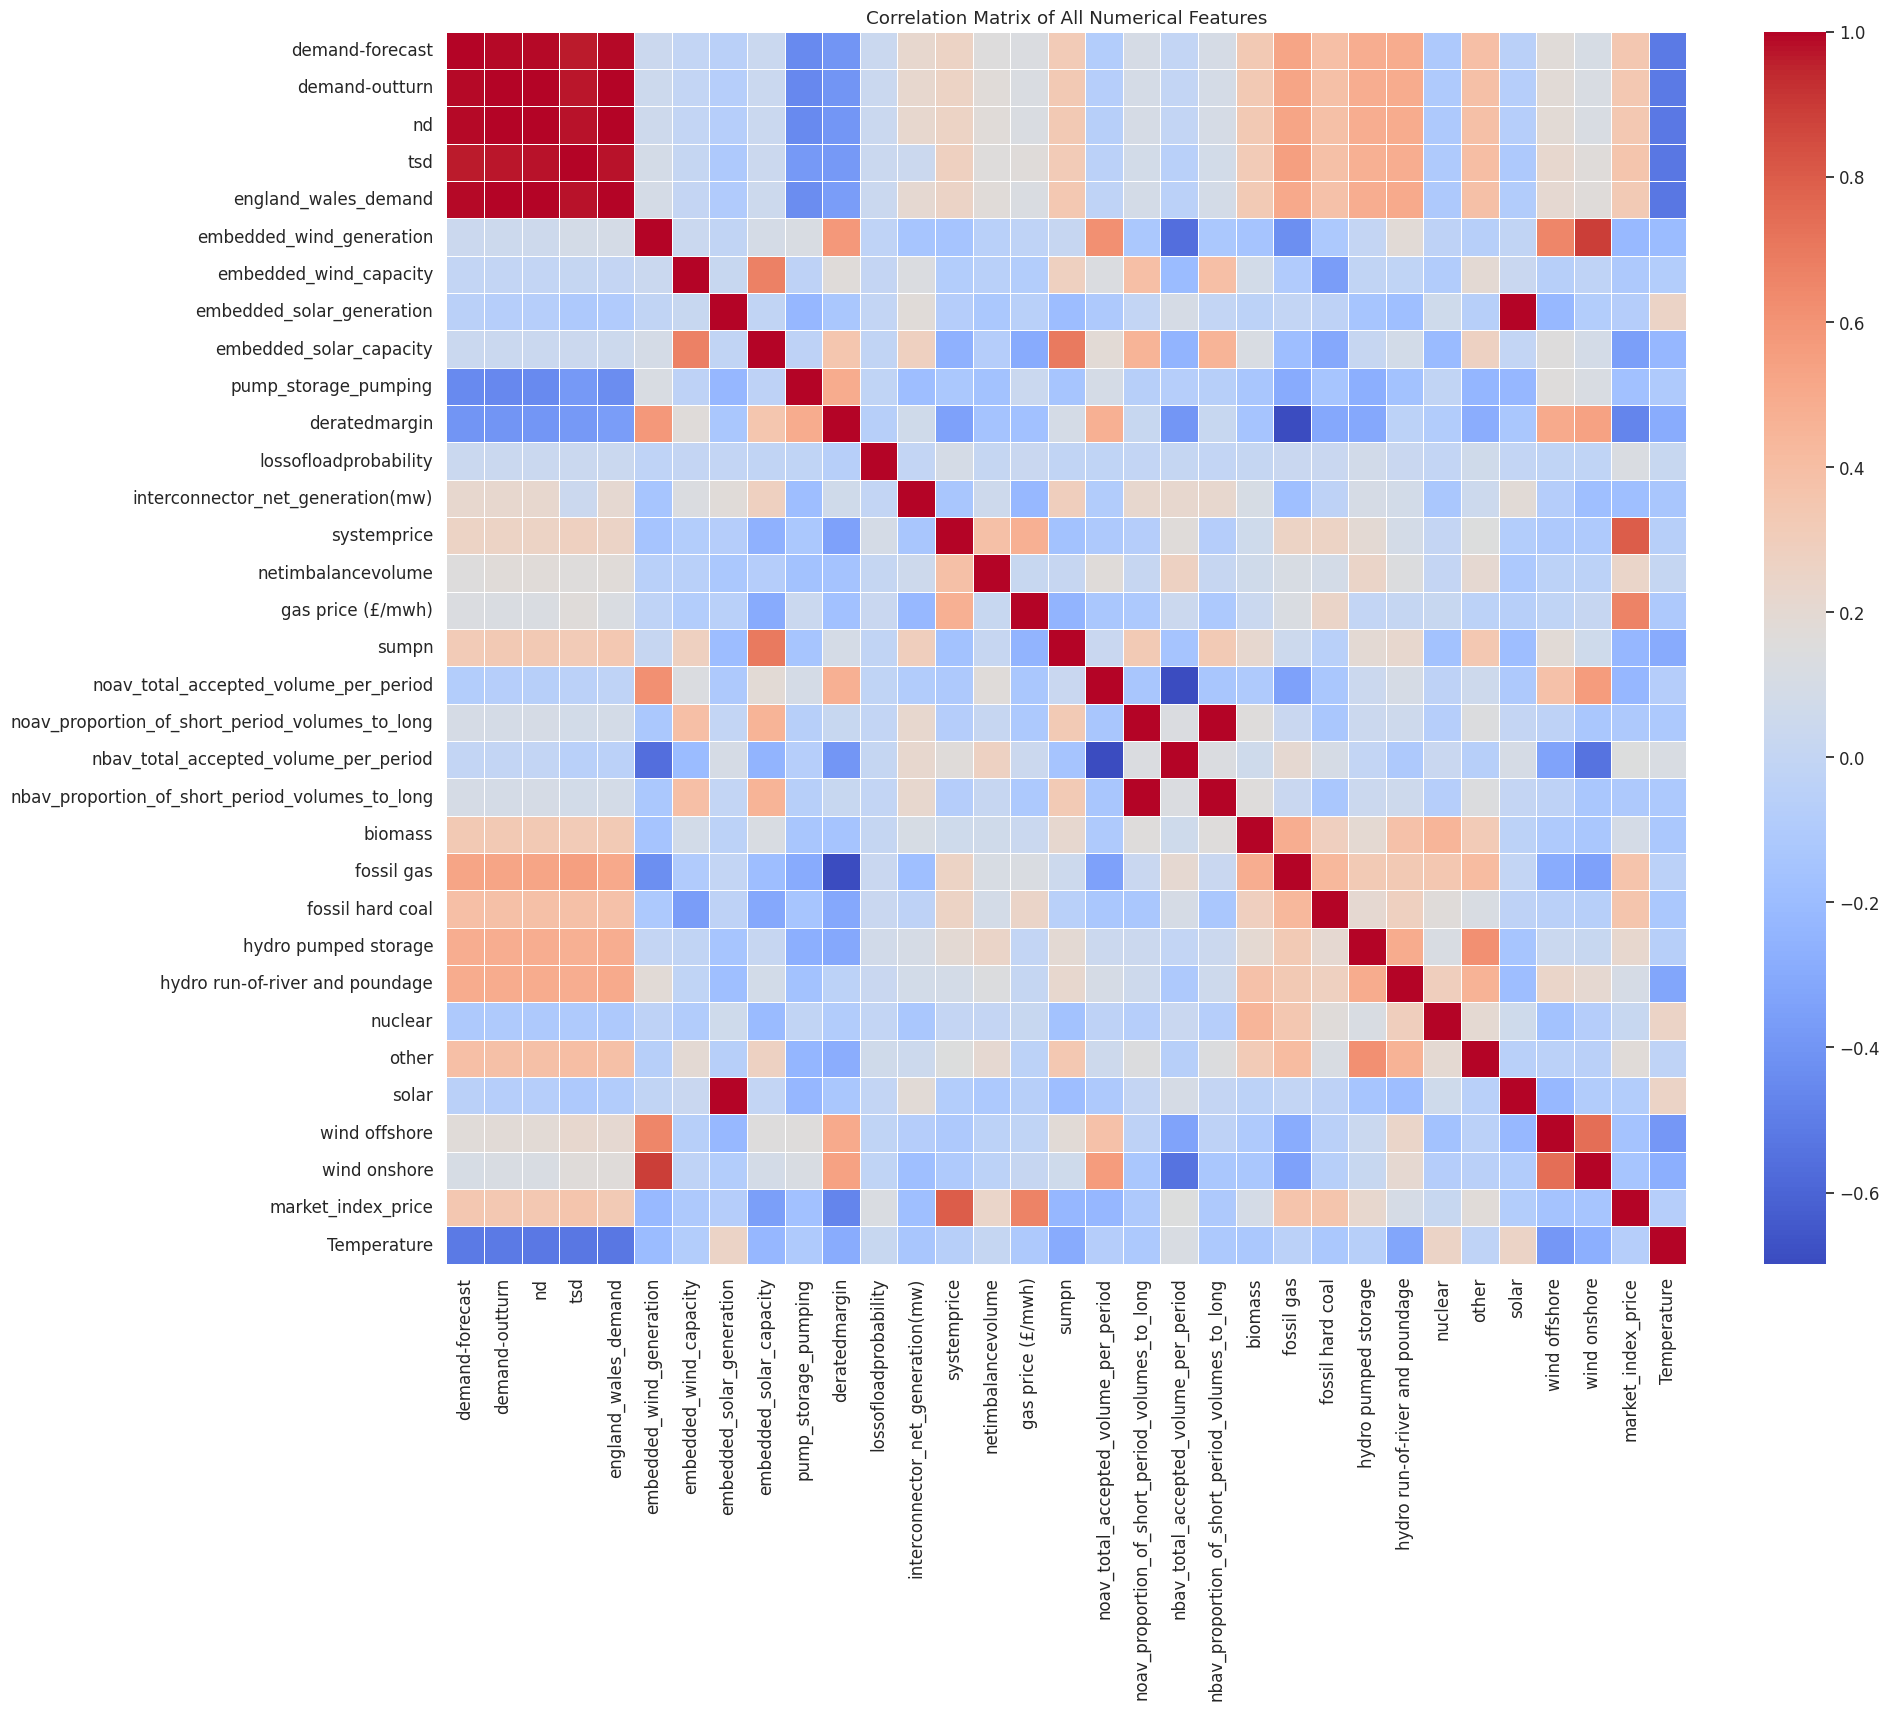

In [ ]:
numeric_df = df[cols].select_dtypes(include=[np.number])

plt.figure(figsize=(20, 16))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of All Numerical Features")
plt.show()


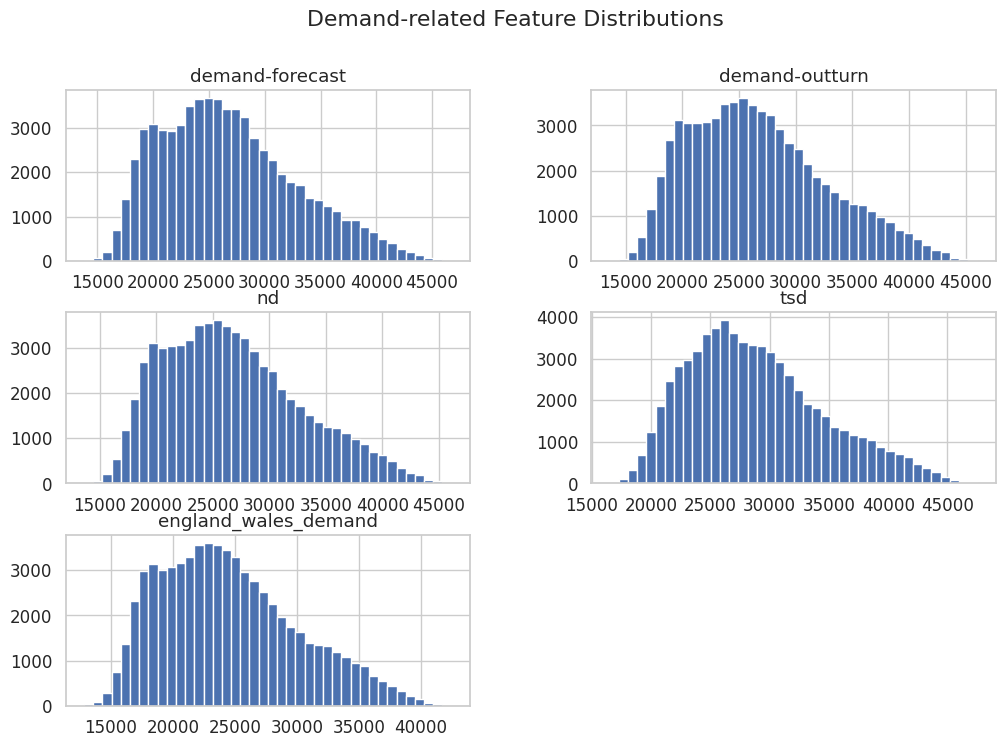

In [ ]:
demand_cols = [
    'demand-forecast','demand-outturn','nd','tsd',
    'england_wales_demand'
]

df[demand_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Demand-related Feature Distributions")
plt.show()


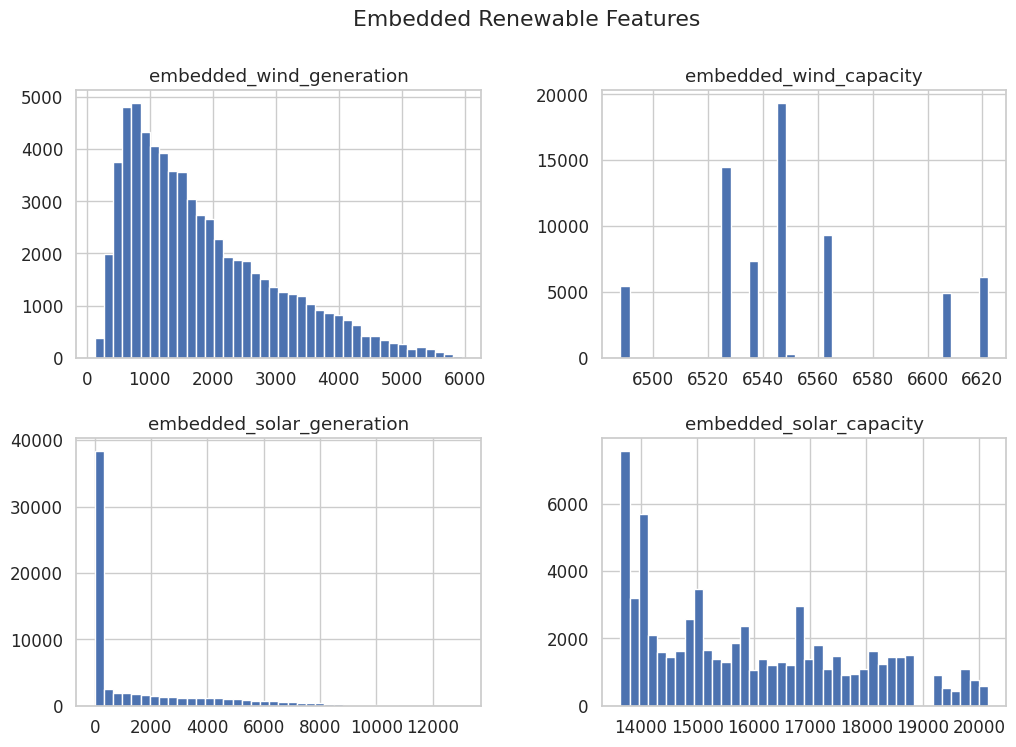

In [ ]:
embedded_cols = [
    'embedded_wind_generation','embedded_wind_capacity',
    'embedded_solar_generation','embedded_solar_capacity'
]

df[embedded_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Embedded Renewable Features")
plt.show()


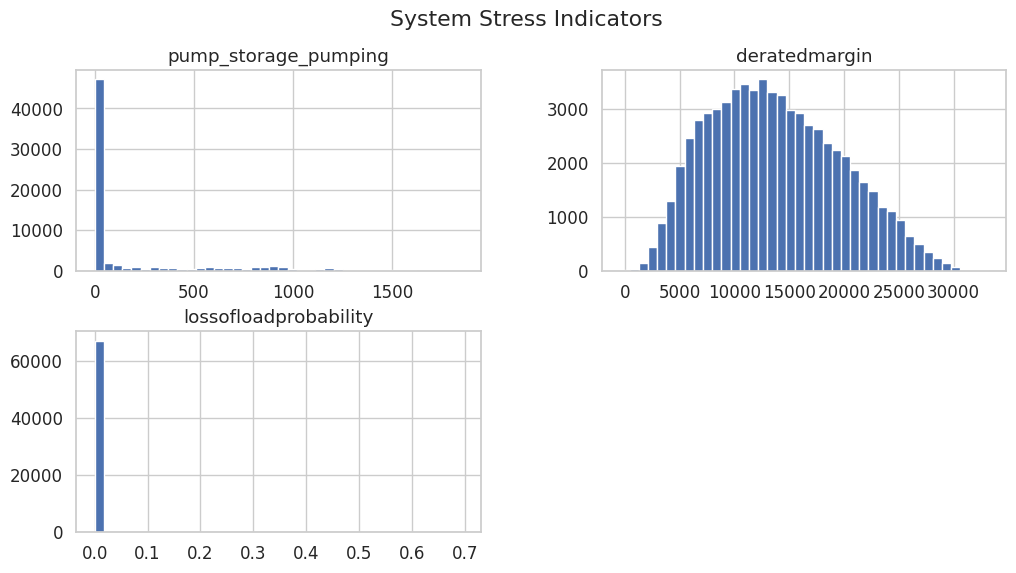

In [ ]:
stress_cols = [
    'pump_storage_pumping', 'deratedmargin', 'lossofloadprobability'
]

df[stress_cols].hist(figsize=(12,6), bins=40)
plt.suptitle("System Stress Indicators")
plt.show()


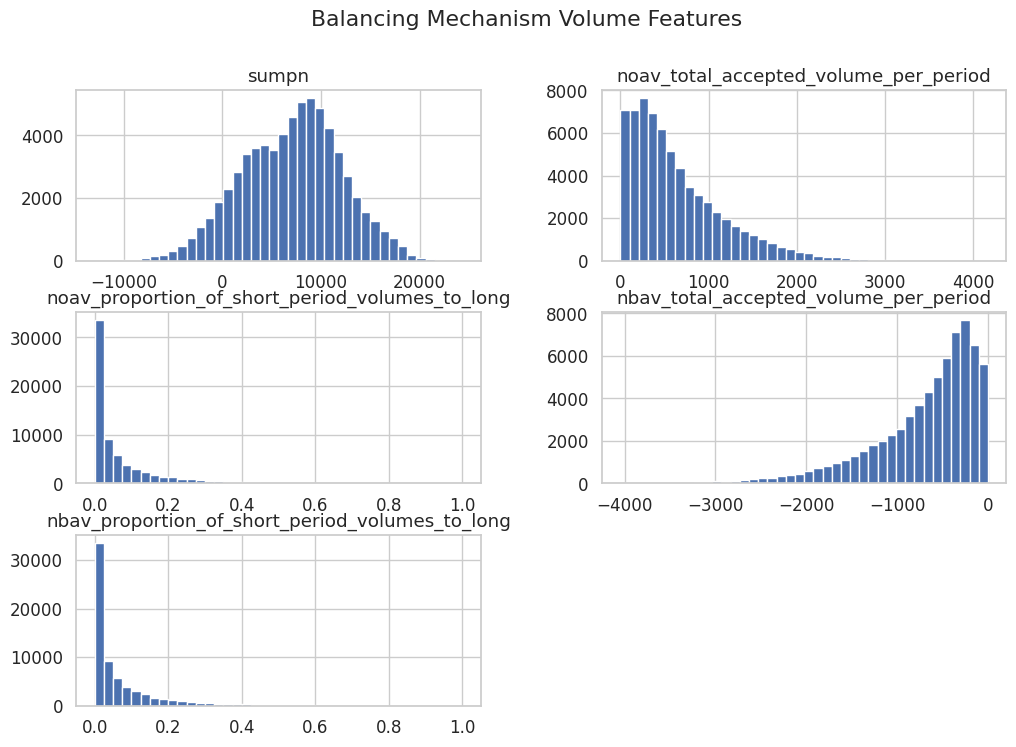

In [ ]:
bm_cols = [
    'sumpn',
    'noav_total_accepted_volume_per_period',
    'noav_proportion_of_short_period_volumes_to_long',
    'nbav_total_accepted_volume_per_period',
    'nbav_proportion_of_short_period_volumes_to_long',
]

df[bm_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Balancing Mechanism Volume Features")
plt.show()


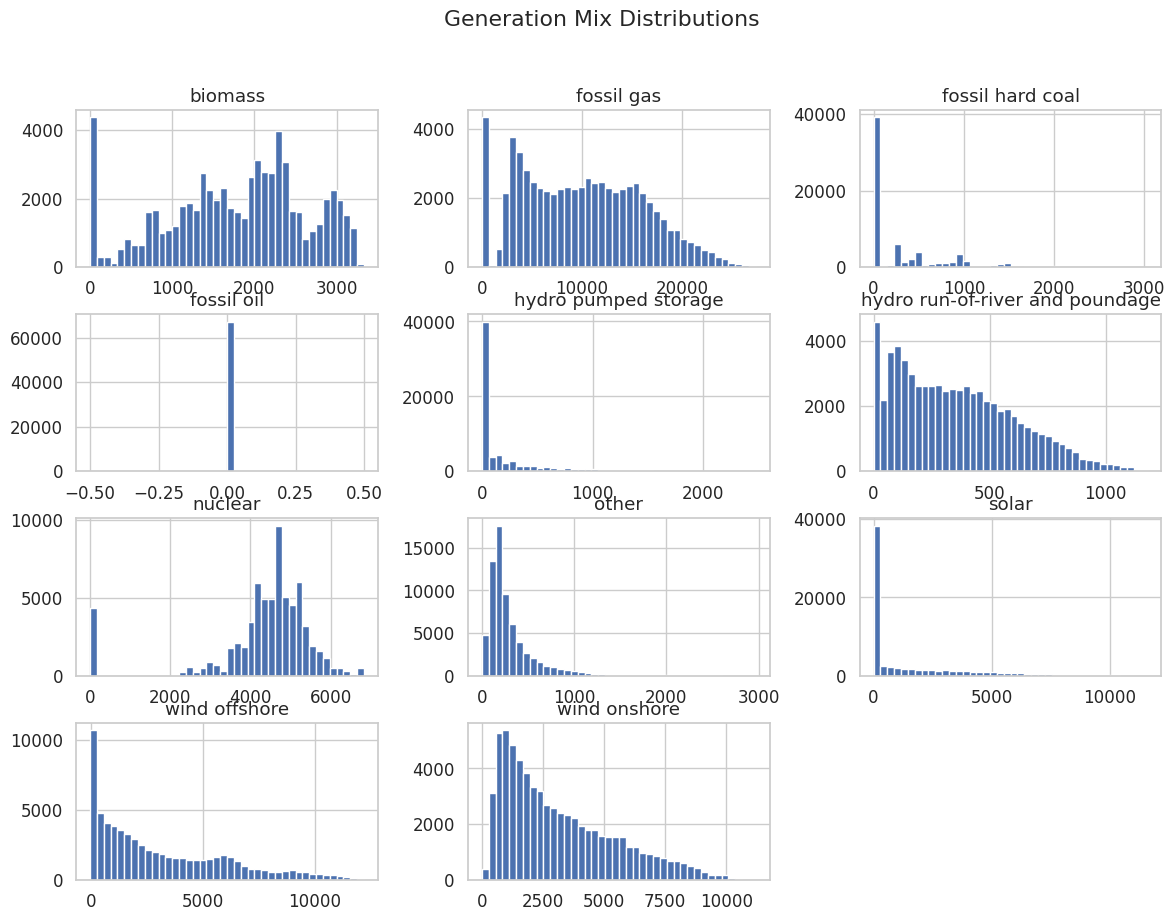

In [ ]:
gen_cols = [
    'biomass','fossil gas','fossil hard coal','fossil oil',
    'hydro pumped storage','hydro run-of-river and poundage',
    'nuclear','other','solar','wind offshore','wind onshore'
]

df[gen_cols].hist(figsize=(14,10), bins=40)
plt.suptitle("Generation Mix Distributions")
plt.show()


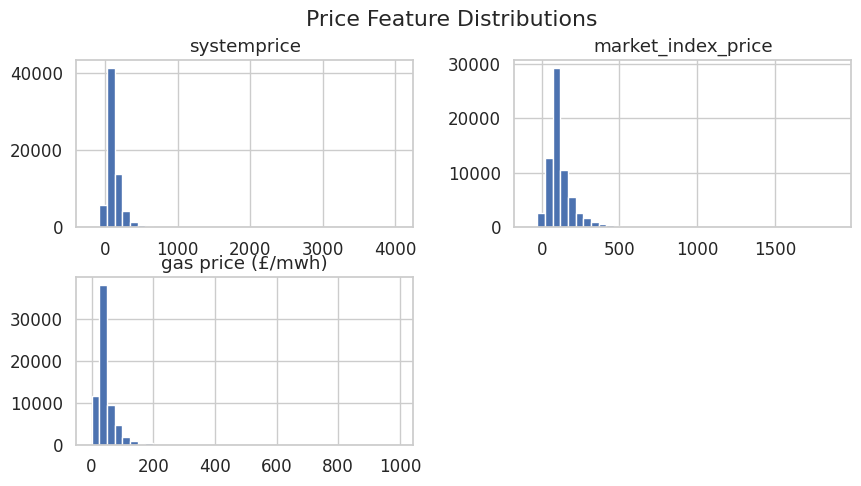

In [ ]:
price_cols = [
    'systemprice','market_index_price','gas price (£/mwh)'
]

df[price_cols].hist(figsize=(10,5), bins=40)
plt.suptitle("Price Feature Distributions")
plt.show()


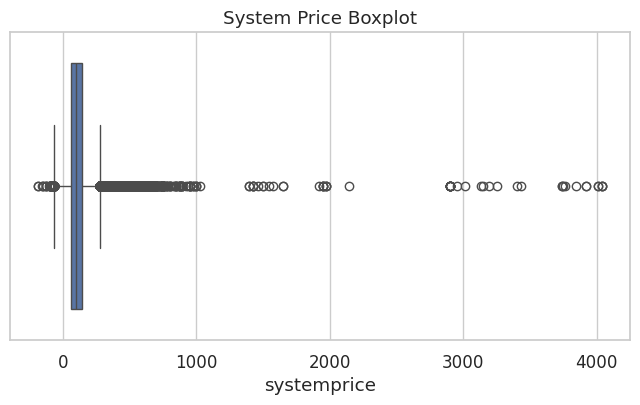

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['systemprice'])
plt.title("System Price Boxplot")
plt.show()


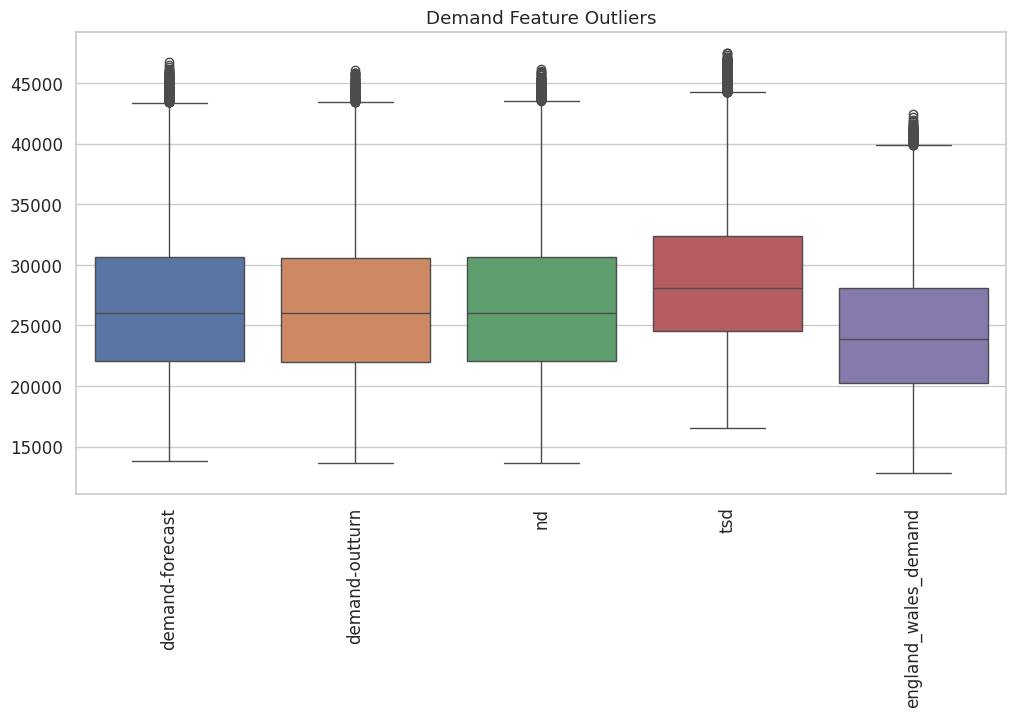

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[demand_cols])
plt.xticks(rotation=90)
plt.title("Demand Feature Outliers")
plt.show()


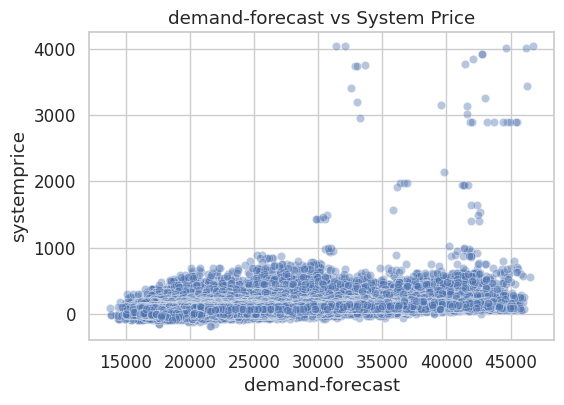

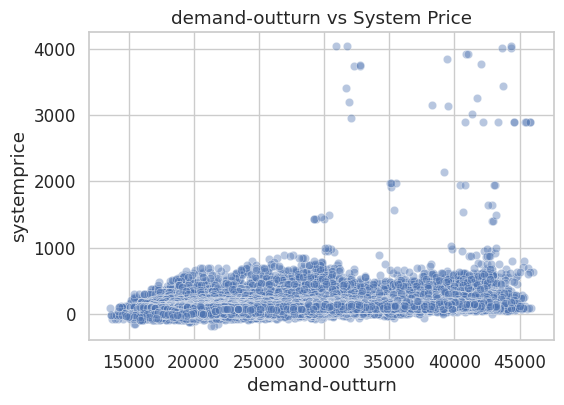

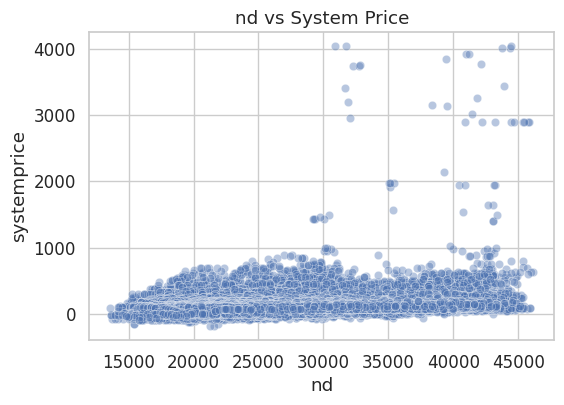

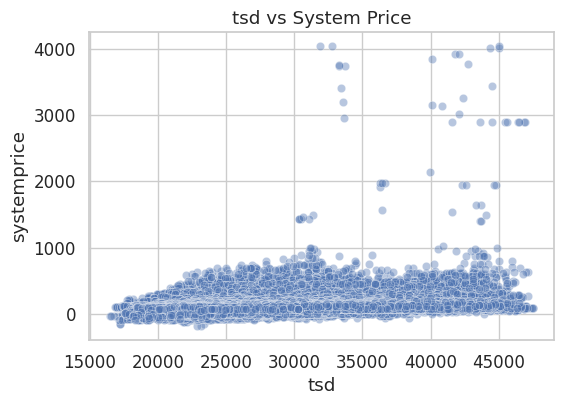

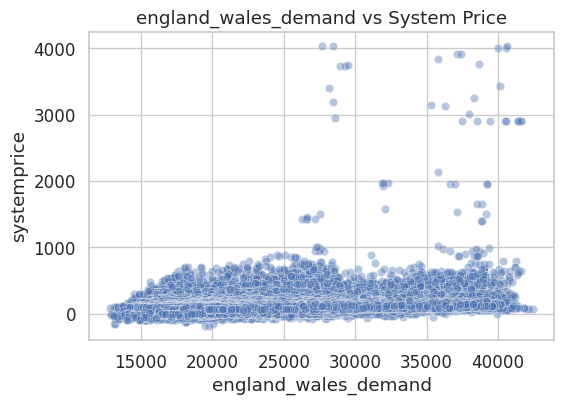

In [ ]:
for col in demand_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['systemprice'], alpha=0.4)
    plt.title(f"{col} vs System Price")
    plt.show()


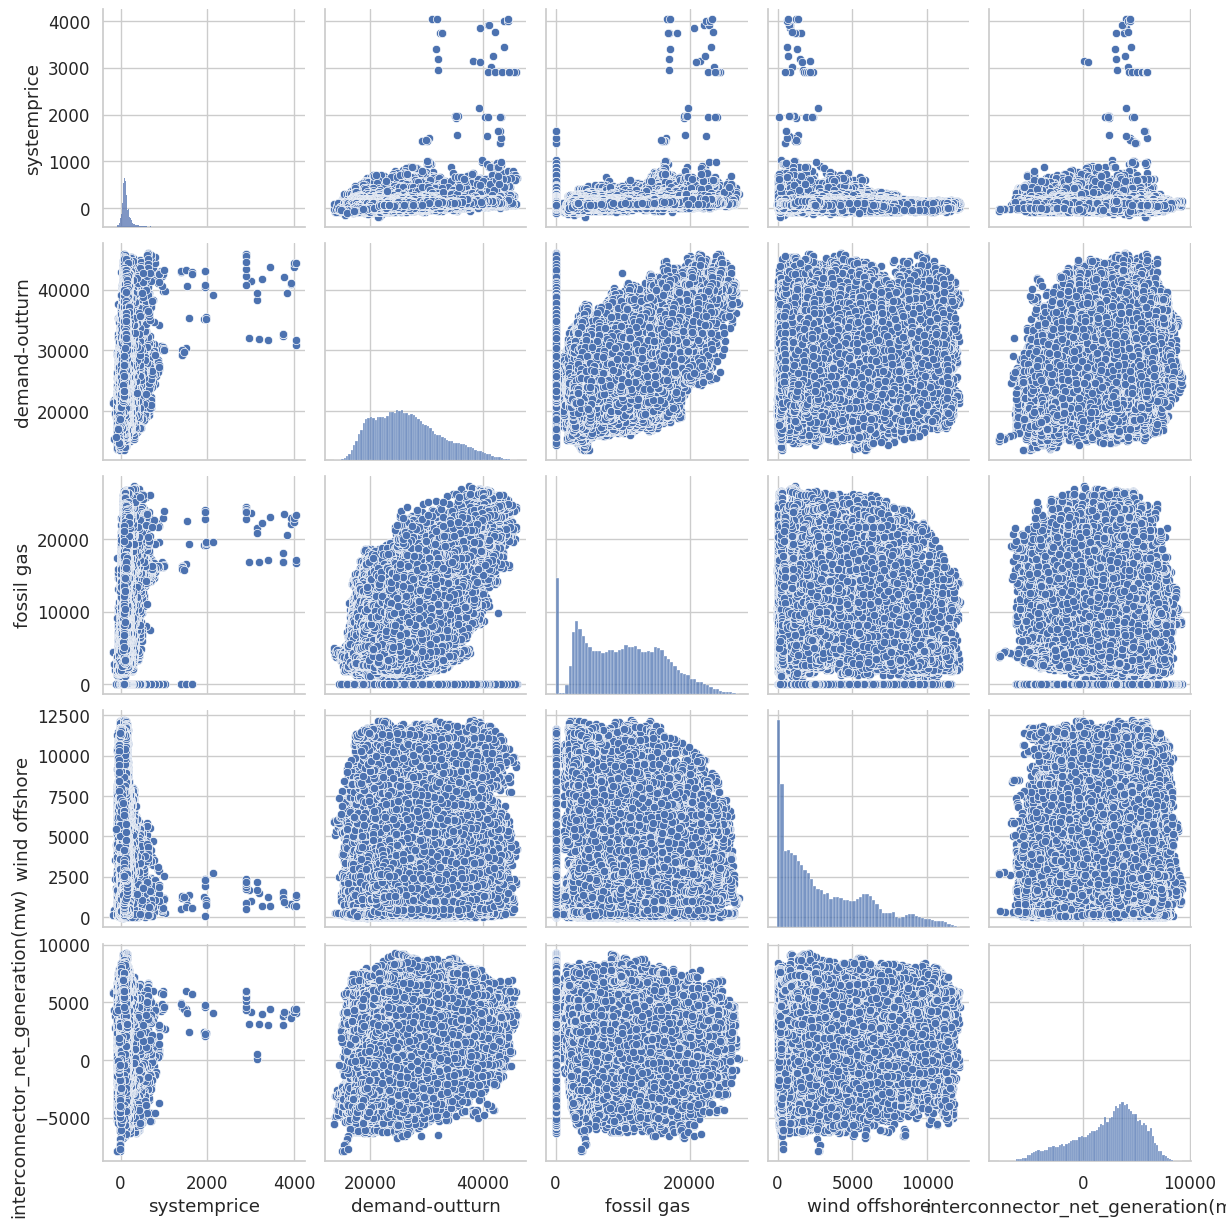

In [ ]:
subset = df[['systemprice','demand-outturn','fossil gas','wind offshore','interconnector_net_generation(mw)']]
sns.pairplot(subset)
plt.show()


Guang's part

Propose to remove correlated variables to remove multicollinearity (For our linear regression portion)
1st step: identifying highly correlated variables.

drop_list = [
    'embedded_solar_generation',
    'embedded_wind_generation',
    'Demand-outturn',
    'england_wales_demand',
    'embedded_wind_capacity',
    'embedded_solar_capacity',
    'noav_proportion_of_short_period_volumes_to_long',
    'nbav_proportion_of_short_period_volumes_to_long',
    'tsd',
    'lossofloadprobability',
    'fossil oil',
    'demand-outturn',
    'nd',
    'netimbalancevolume',
    'noav_total_accepted_volume_per_period',
    'nbav_total_accepted_volume_per_period']

Merged [wind onshore and wind offshore to total wind energy ]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

file_path = "/Users/chuaguangwei/Desktop/UCL /UCL - Rey/BEVN 91/Project /Data/Merged EDA clean data /merged_cleaned_data_for_EDA.csv"
df = pd.read_csv(file_path)

df.head()


,date_sp,demand-forecast,demand-outturn,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,fossil oil,hydro pumped storage,hydro run-of-river and poundage,nuclear,other,solar,wind offshore,wind onshore,market_index_price,Temperature
0,2021-04-01-01,21570.0,19970.0,19994,21312,18253,2046,6527,0,13637,...,0.0,0.0,723.0,4898.0,153.0,0.0,2264.986,4179.700,54.31,16.0
1,2021-04-01-02,21130.0,20030.0,19999,21438,18244,2095,6527,0,13642,...,0.0,0.0,723.0,4884.0,150.0,0.0,2490.455,3707.783,46.73,16.0
2,2021-04-01-03,21272.0,20499.0,20482,21701,18745,2082,6527,0,13642,...,0.0,0.0,721.0,4895.0,162.0,0.0,3707.667,3562.915,43.00,16.0
3,2021-04-01-04,21600.0,20940.0,20926,21723,19183,2091,6527,0,13642,...,0.0,0.0,720.0,4894.0,148.0,0.0,3930.858,3677.153,46.65,16.0
4,2021-04-01-05,21478.0,20682.0,20685,21728,18945,2178,6527,0,13642,...,0.0,0.0,704.0,4894.0,149.0,0.0,3854.118,3673.495,51.15,16.0


To determine the highest correalated features.

In [ ]:
corr_matrix = df.corr(numeric_only=True)
pairs = corr_matrix.unstack()

sorted_pairs = pairs.sort_values(kind="quicksort", ascending=False)


#  Keep only values > 0.8 or < -0.8 ie Highly correlated variables.
strong_pairs = sorted_pairs[
    (abs(sorted_pairs) > 0.8) &
    (sorted_pairs != 1.0)]

# Remove duplicates
unique_strong_pairs = strong_pairs[strong_pairs.index.map(lambda x: x[0] < x[1])]
print("Highly Correlated Pairs (> 0.8 or < -0.8):")
print(unique_strong_pairs)

Highly Correlated Pairs (> 0.8 or < -0.8):
demand-outturn             nd                      0.999935
england_wales_demand       nd                      0.997633
demand-outturn             england_wales_demand    0.997471
embedded_solar_generation  solar                   0.996249
demand-forecast            nd                      0.990622
                           demand-outturn          0.990558
                           england_wales_demand    0.987441
england_wales_demand       tsd                     0.975062
nd                         tsd                     0.973550
demand-outturn             tsd                     0.973373
demand-forecast            tsd                     0.964122
embedded_wind_generation   wind onshore            0.889239
dtype: float64


1) To drop ['embedded_solar_generation','embedded_wind_generation'] due to high correlation with 'wind onshore' and 'solar'
2) To drop ['embedded_wind_capacity','embedded_solar_capacity'] since it doesnt explain anything. This is just the present capacity. Likely not much changes.
Current drop list ['embedded_solar_generation','embedded_wind_generation','embedded_wind_capacity','embedded_solar_capacity']

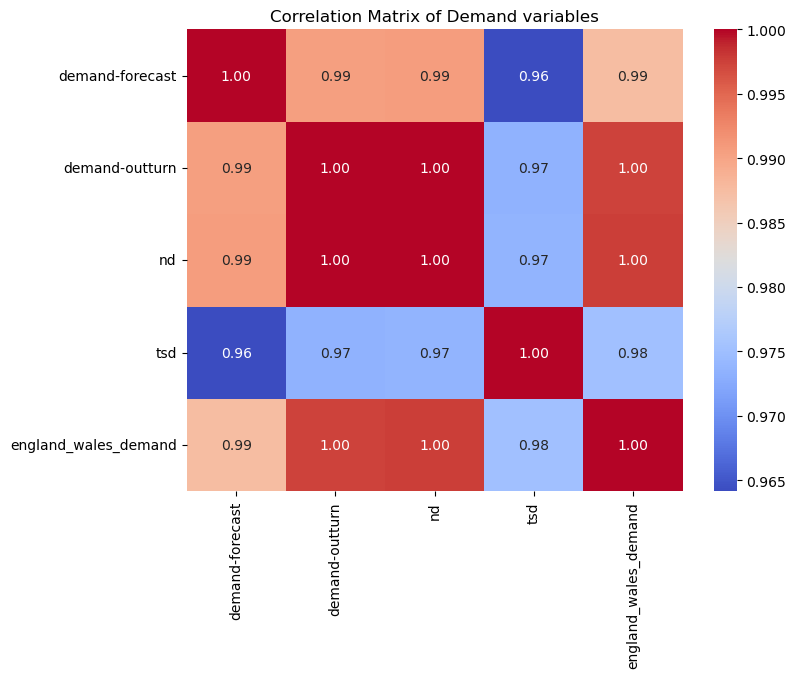

In [ ]:
#plotting a demand side corr map - which is top left corner of Ahana's corr map
demand_cols = ['demand-forecast', 'demand-outturn', 'nd', 'tsd', 'england_wales_demand']
corr_matrix = df[demand_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm")
plt.title("Correlation Matrix of Demand variables")
plt.show()

2) Proposed to drop - ['Demand-outturn','england_wales_demand'] due to high correlation with nd. Essentially same data with no new info gain.

Current drop list ['embedded_solar_generation','embedded_wind_generation','Demand-outturn','england_wales_demand','embedded_wind_capacity','embedded_solar_capacity']

3) Undecided whether to keep tsd or nd. Only can keep 1. - To discuss. I think better to drop tsd. Nevermind.. both was dropped.

Gemini:
Drop tsd if you are predicting market prices or consumer behavior (use nd instead).
Keep tsd (and drop nd) ONLY if you are an electrical engineer modeling physical wire stress or total generation capacity requirements.




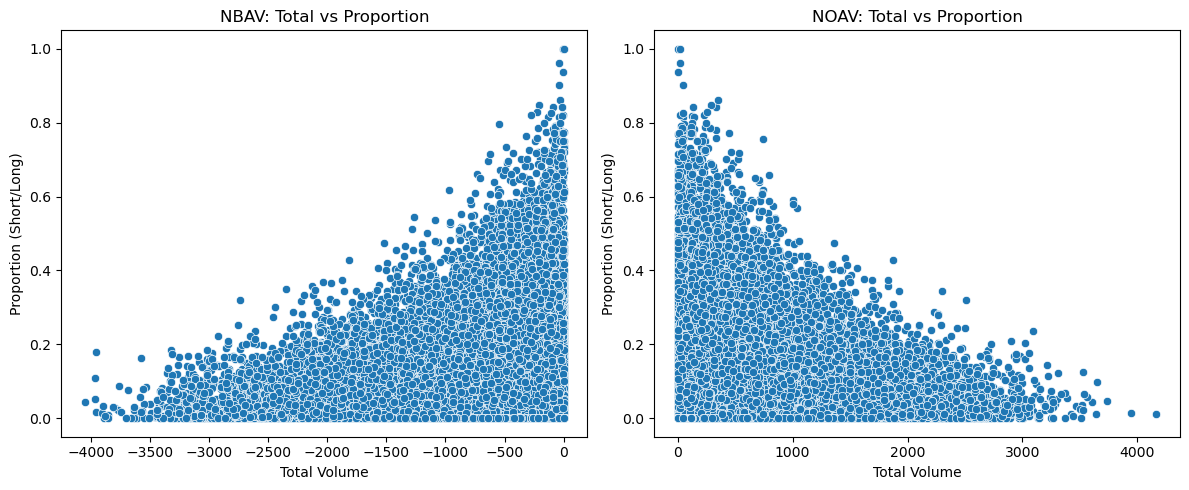

In [ ]:
#scatter plot of nbav and noav

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['nbav_total_accepted_volume_per_period'],
                y=df['nbav_proportion_of_short_period_volumes_to_long'])
plt.title('NBAV: Total vs Proportion')
plt.xlabel('Total Volume')
plt.ylabel('Proportion (Short/Long)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['noav_total_accepted_volume_per_period'],
                y=df['noav_proportion_of_short_period_volumes_to_long'])
plt.title('NOAV: Total vs Proportion')
plt.xlabel('Total Volume')
plt.ylabel('Proportion (Short/Long)')

plt.tight_layout()
plt.savefig('proof_of_redundancy.png')

noav_proportion_of_short_period_volumes_to_long - Net Offers Accepted Volume
nbav_proportion_of_short_period_volumes_to_long - Net Bids Accepted Volume

These are proportion features that gives us info on the composition rather than the actual value. We should keep 'nbav_total_accepted_volume_per_period'
Even when the heatmap shows 0 correlation but the dependency is sill extremely strong. So we should drop  ['noav_proportion_of_short_period_volumes_to_long',
'nbav_proportion_of_short_period_volumes_to_long'] and keep 'nbav_total_accepted_volume_per_period' and 'noav_total_accepted_volume_per_period'

Current drop list ['embedded_solar_generation','embedded_wind_generation','Demand-outturn','england_wales_demand','embedded_wind_capacity','embedded_solar_capacity','noav_proportion_of_short_period_volumes_to_long',
'nbav_proportion_of_short_period_volumes_to_long','tsd']


Let's calculate NIV = NOAV + NBAV. We create a new feature (Sum of NOAV and NBAV) to compare with NIV
Solely based on collinearity, we should keep all 3. BUT..

If we use the actual either NIV NOAV or NBAV, there will be data leakage. It is like telling the model the direction before it even tries to predict it.

Correlation between (NOAV + NBAV) and NIV: 0.561


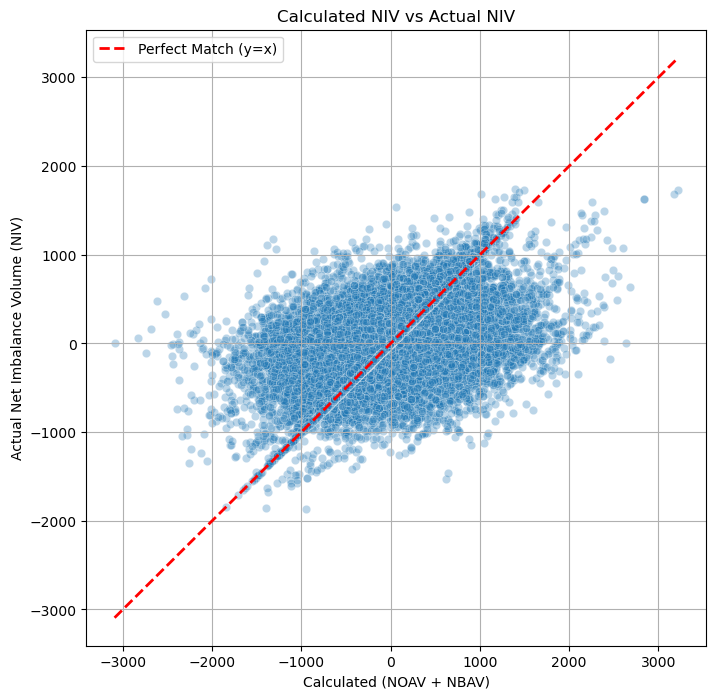

In [ ]:

df['calculated_NIV'] = df['noav_total_accepted_volume_per_period'] + df['nbav_total_accepted_volume_per_period']
correlation = df['calculated_NIV'].corr(df['netimbalancevolume'])
print(f"Correlation between (NOAV + NBAV) and NIV: {correlation:.3f}")

#plot
plt.figure(figsize=(8, 8))


sns.scatterplot(x=df['calculated_NIV'], y=df['netimbalancevolume'], alpha=0.3)
min_val = min(df['calculated_NIV'].min(), df['netimbalancevolume'].min())
max_val = max(df['calculated_NIV'].max(), df['netimbalancevolume'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Match (y=x)')
plt.title('Calculated NIV vs Actual NIV')
plt.xlabel('Calculated (NOAV + NBAV)')
plt.ylabel('Actual Net Imbalance Volume (NIV)')
plt.legend()
plt.grid(True)
plt.show()

#clean
df = df.drop(columns=['calculated_NIV'])

'demand-outturn', 'demand-forecast' and 'nd' has a correlation of >0.99. essentially no new information.
To drop 'demand-outturn' and 'nd' since they are actual values measure after - Data leakage. ie Keep 'demand-forecast'



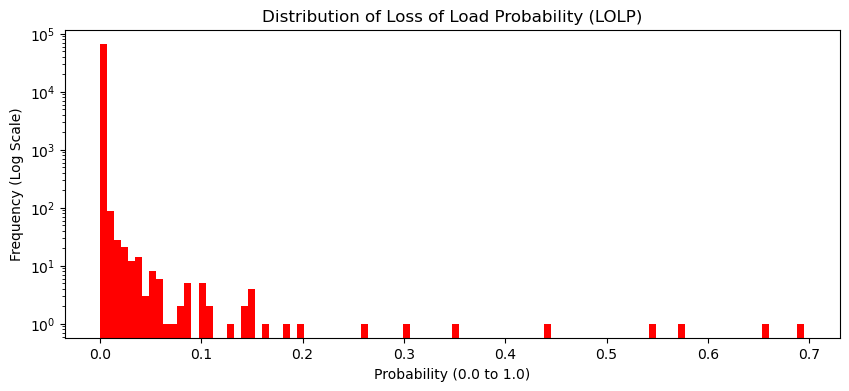

Total Rows: 67262
Rows with roughly Zero Probability: 63430
Percentage of 'Dead' Data: 94.3029%


In [ ]:
# Visual Proof: The Histogram for LOLP
plt.figure(figsize=(10, 4))
plt.hist(df['lossofloadprobability'], bins=100, color='red', log=True) # Log scale to see the tiny non-zero values
plt.title('Distribution of Loss of Load Probability (LOLP)')
plt.xlabel('Probability (0.0 to 1.0)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# Statistical Proof: The "Zero" Count
zeros = (df['lossofloadprobability'] <= 0.000001).sum()
total = len(df)
print(f"Total Rows: {total}")
print(f"Rows with roughly Zero Probability: {zeros}")
print(f"Percentage of 'Dead' Data: {zeros/total:.4%}")

The 3,832 rows where LOLP > 0 are not random. They are the exact same 3,832 rows where your deratedmargin is low.

Feature A (deratedmargin): Tells you the grid is "Tight" (e.g., Margin = 500MW).

Feature B (LOLP): Tells you the grid is "Tight" (e.g., Probability = 0.5).

Since Feature A (deratedmargin) covers 100% of the data (it tells you when the grid is safe, tight, and critical) and Feature B (LOLP) only wakes up for the "critical" 5%, Feature A is strictly better. Keeping both confuses the model with duplicate information.

Models like RF and XGBoost do not need pre-calculated LOLP column. They can use deratedmargin column.

Suggest to drop LOLP.

Current drop list ['embedded_solar_generation','embedded_wind_generation','Demand-outturn','england_wales_demand','embedded_wind_capacity','embedded_solar_capacity','noav_proportion_of_short_period_volumes_to_long',
'nbav_proportion_of_short_period_volumes_to_long','tsd','lossofloadprobability']


In [ ]:
#Merging WInd resources
df['total_wind_forecast'] = df['wind offshore'] + df['wind onshore']
df = df.drop(columns=['wind offshore', 'wind onshore'])
print(df[['total_wind_forecast', 'systemprice']].corr())

                     total_wind_forecast  systemprice
total_wind_forecast             1.000000    -0.112513
systemprice                    -0.112513     1.000000


Original Column Count: 34
New Column Count: 19


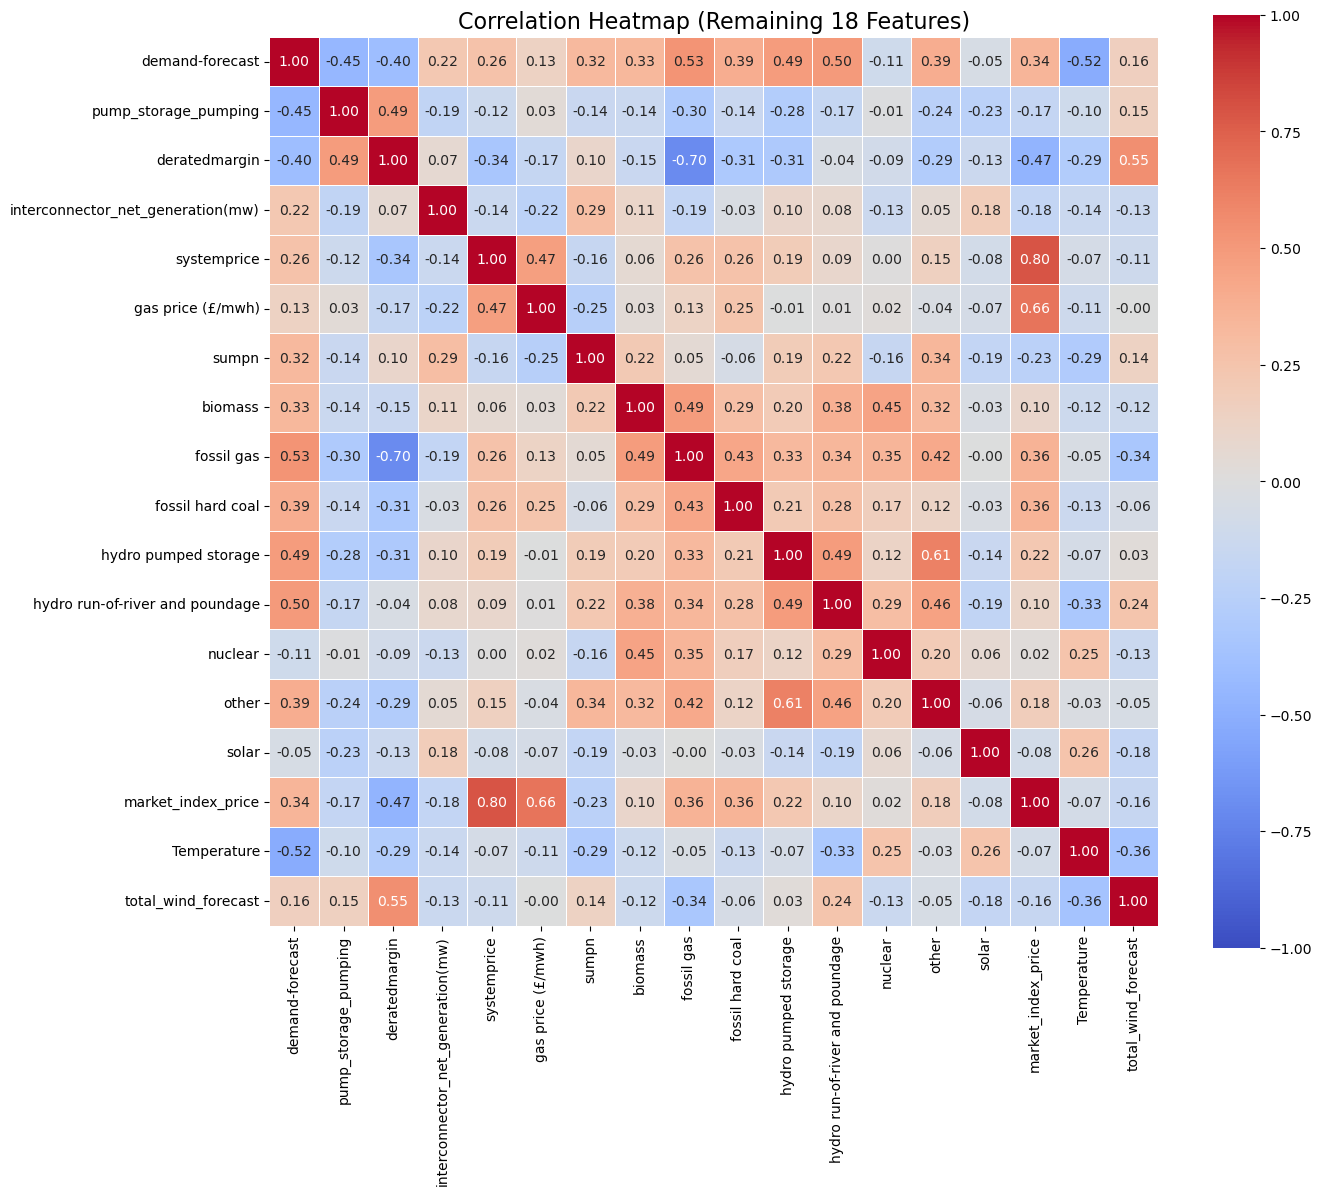

In [ ]:
#Create a temp df with the proposed features dropped. replot the heat map
drop_list = [
    'embedded_solar_generation',
    'embedded_wind_generation',
    'Demand-outturn',
    'england_wales_demand',
    'embedded_wind_capacity',
    'embedded_solar_capacity',
    'noav_proportion_of_short_period_volumes_to_long',
    'nbav_proportion_of_short_period_volumes_to_long',
    'tsd',
    'lossofloadprobability',
    'fossil oil',
    'demand-outturn',
    'nd',
    'netimbalancevolume',
    'noav_total_accepted_volume_per_period',
    'nbav_total_accepted_volume_per_period']
temp_df = df.drop(columns=drop_list, errors='ignore')
print(f"Original Column Count: {df.shape[1]}")
print(f"New Column Count: {temp_df.shape[1]}")

numerical_temp_df = temp_df.select_dtypes(include=['number'])
corr_matrix = numerical_temp_df.corr()

#replot heatmap
plt.figure(figsize=(14, 12))  # Large size to make labels readable
sns.heatmap(
    corr_matrix,
    annot=True,       # Show the numbers on the boxes
    fmt=".2f",        # Format to 2 decimal places
    cmap='coolwarm',  # Red = Positive, Blue = Negative
    center=0,         # Center color map at 0
    vmin=-1, vmax=1,  # Fix scale from -1 to 1
    linewidths=0.5,   # Add white lines between squares
    square=True       # Force squares for better aspect ratio
)

plt.title(f"Correlation Heatmap (Remaining {len(numerical_temp_df.columns)} Features)", fontsize=16)
plt.tight_layout()
plt.show()

Finding Baseline feature importance usigng RF

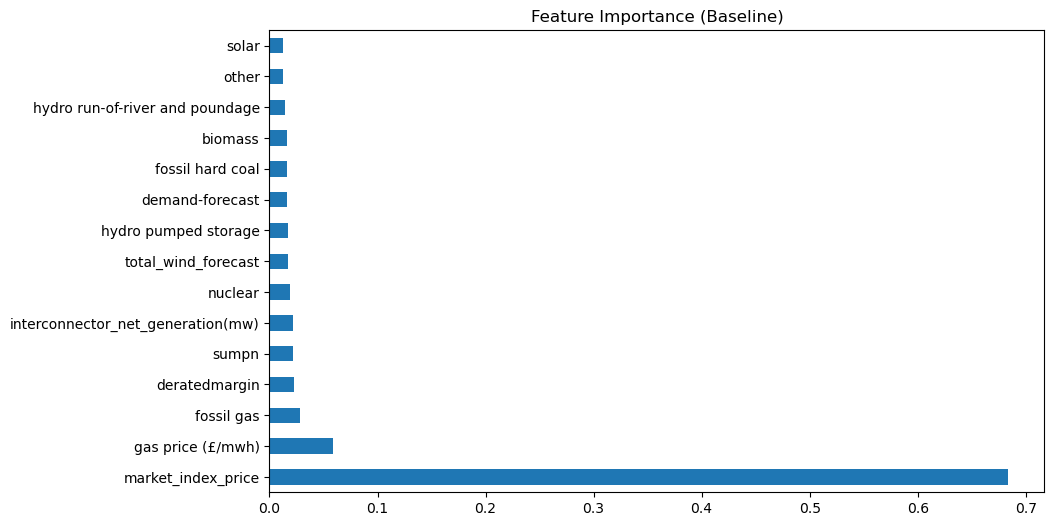

In [ ]:

# Define X and y
X = numerical_temp_df.drop(columns=['systemprice'])
y = numerical_temp_df['systemprice']

# Train the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# plot
importances = rf.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Feature Importance (Baseline)")
plt.show()

In [ ]:
#Creating net_demand
# This represents the "residual load" that expensive fossil fuels must meet.
# Formula: Demand - (Wind + Solar)
temp_df['net_demand'] = temp_df['demand-forecast'] - (temp_df['total_wind_forecast'] + temp_df['solar'])
# When Net Demand is high AND Gas Prices are high, System Price explodes.
# This interaction feature helps linear models see that relationship.
temp_df['stress_factor'] = temp_df['net_demand'] * temp_df['gas price (£/mwh)']
print(temp_df[['systemprice', 'net_demand', 'stress_factor']].corr())

               systemprice  net_demand  stress_factor
systemprice       1.000000    0.314178       0.554951
net_demand        0.314178    1.000000       0.540846
stress_factor     0.554951    0.540846       1.000000


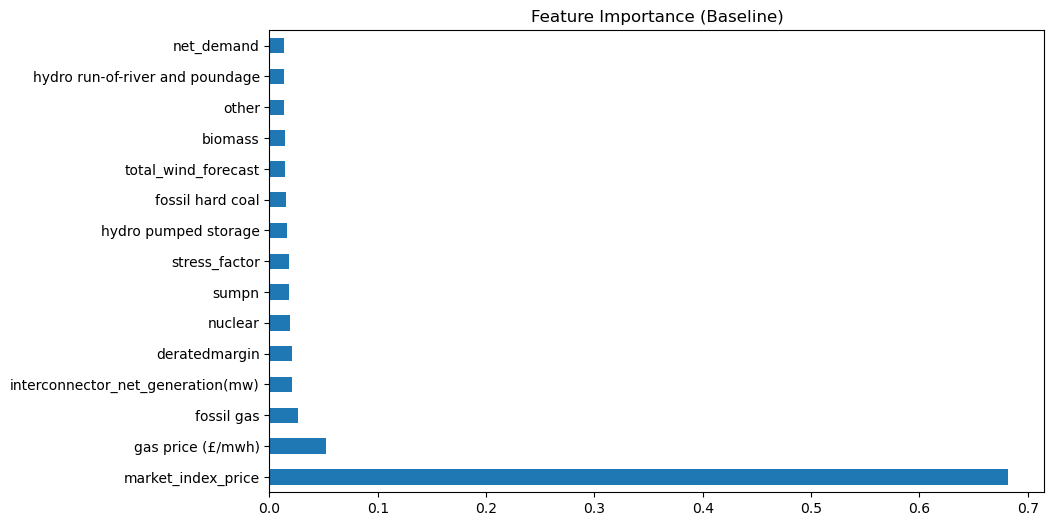

In [ ]:
#Feature Importance after adding new features
# Define X and y
numerical_temp_df = temp_df.select_dtypes(include=['number'])
X = numerical_temp_df.drop(columns=['systemprice'])
y = numerical_temp_df['systemprice']

# Train the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# plot
importances = rf.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Feature Importance (Baseline)")
plt.show()

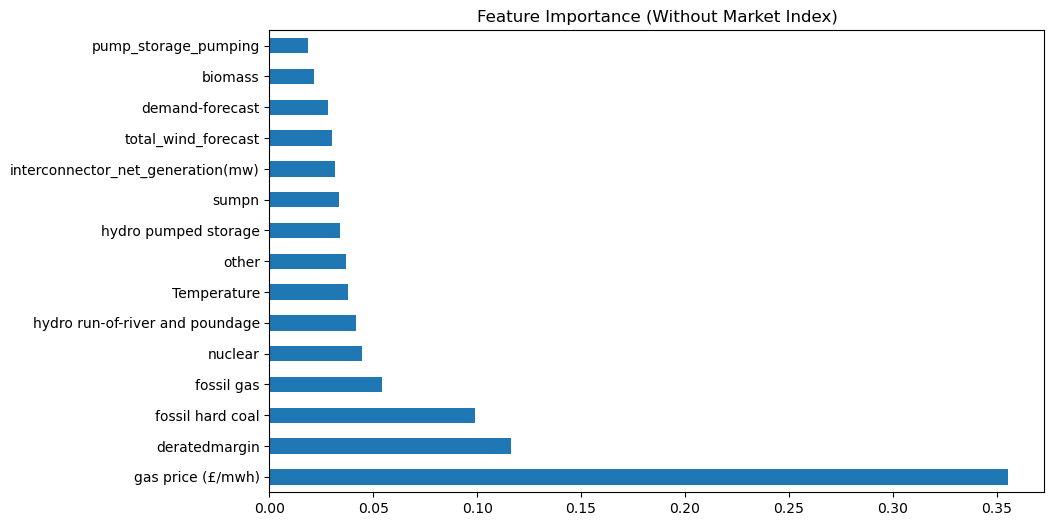

In [ ]:
# 1. TEMPORARY TEST: Drop the Market Index to force the model to learn physics
# We also keep 'stress_factor' and 'net_demand'
X_fundamental = numerical_temp_df.drop(columns=['systemprice', 'market_index_price','stress_factor','net_demand'])
y = numerical_temp_df['systemprice']

rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
rf_test.fit(X_fundamental, y)

importances = rf_test.feature_importances_
feat_importances = pd.Series(importances, index=X_fundamental.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Feature Importance (Without Market Index)")
plt.show()

In [ ]:
#updating of the new file
numerical_temp_df.info()
updated_df = numerical_temp_df.drop(columns=['market_index_price','stress_factor','net_demand'])
updated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67262 entries, 0 to 67261
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   demand-forecast                    67262 non-null  float64
 1   pump_storage_pumping               67262 non-null  int64  
 2   deratedmargin                      67262 non-null  float64
 3   interconnector_net_generation(mw)  67262 non-null  float64
 4   systemprice                        67262 non-null  float64
 5   gas price (£/mwh)                  67262 non-null  float64
 6   sumpn                              67262 non-null  float64
 7   biomass                            67262 non-null  float64
 8   fossil gas                         67262 non-null  float64
 9   fossil hard coal                   67262 non-null  float64
 10  hydro pumped storage               67262 non-null  float64
 11  hydro run-of-river and poundage    67262 non-null  flo

In [ ]:
full_path =  "/Users/chuaguangwei/Desktop/updated_DF(Guang).csv"
updated_df.to_csv(full_path, index=False)